<a href="https://colab.research.google.com/github/n-manato/audio-data-modeling/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition using the RAVDESS Dataset

## Objective
The goal of this notebook is to explore how speech audio can be used to classify emotions.
Using the RAVDESS dataset, I load speech recordings, visualize waveforms and pitch contours, extract pitch-based features, and compare three machine learning models.
This notebook demonstrates a basic workflow for audio processing and speech emotion classification in Google Colab.

# Import Libraries
In this section, I import the Python libraries needed for audio processing, data handling, visualization, and machine learning.

In [1]:
# Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
In this section, I load the speech audio files from the RAVDESS dataset.
I organize the files and prepare them for audio analysis and emotion classification.

In [2]:
# RAVDESS dataset folder path

dataset_path = "./Audio_Speech_Actors_01-24"

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

audio_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Number of audio files:", len(audio_files))
print("First sample file:", os.path.basename(audio_files[0]))

selected_emotions = {"01", "03", "04", "05"}

sample_by_emotion = {}

for file in audio_files:
    filename = os.path.basename(file)
    parts = filename.split("-")
    emotion_code = parts[2]

    if emotion_code in selected_emotions and emotion_code not in sample_by_emotion:
        sample_by_emotion[emotion_code] = file

emotion_order = ["01", "03", "04", "05"]

print("Selected sample files:")
for code in emotion_order:
    print(code, emotion_map[code], "->", os.path.basename(sample_by_emotion[code]))

Number of audio files: 1440
First sample file: 03-01-01-01-01-01-01.wav
Selected sample files:
01 neutral -> 03-01-01-01-01-01-01.wav
03 happy -> 03-01-03-01-01-01-01.wav
04 sad -> 03-01-04-01-01-01-01.wav
05 angry -> 03-01-05-01-01-01-01.wav


# Explore Audio
In this section, I visualize sample audio files using waveforms and pitch contours.
This helps me understand how the speech signal and vocal pitch change over time before building a model.

c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


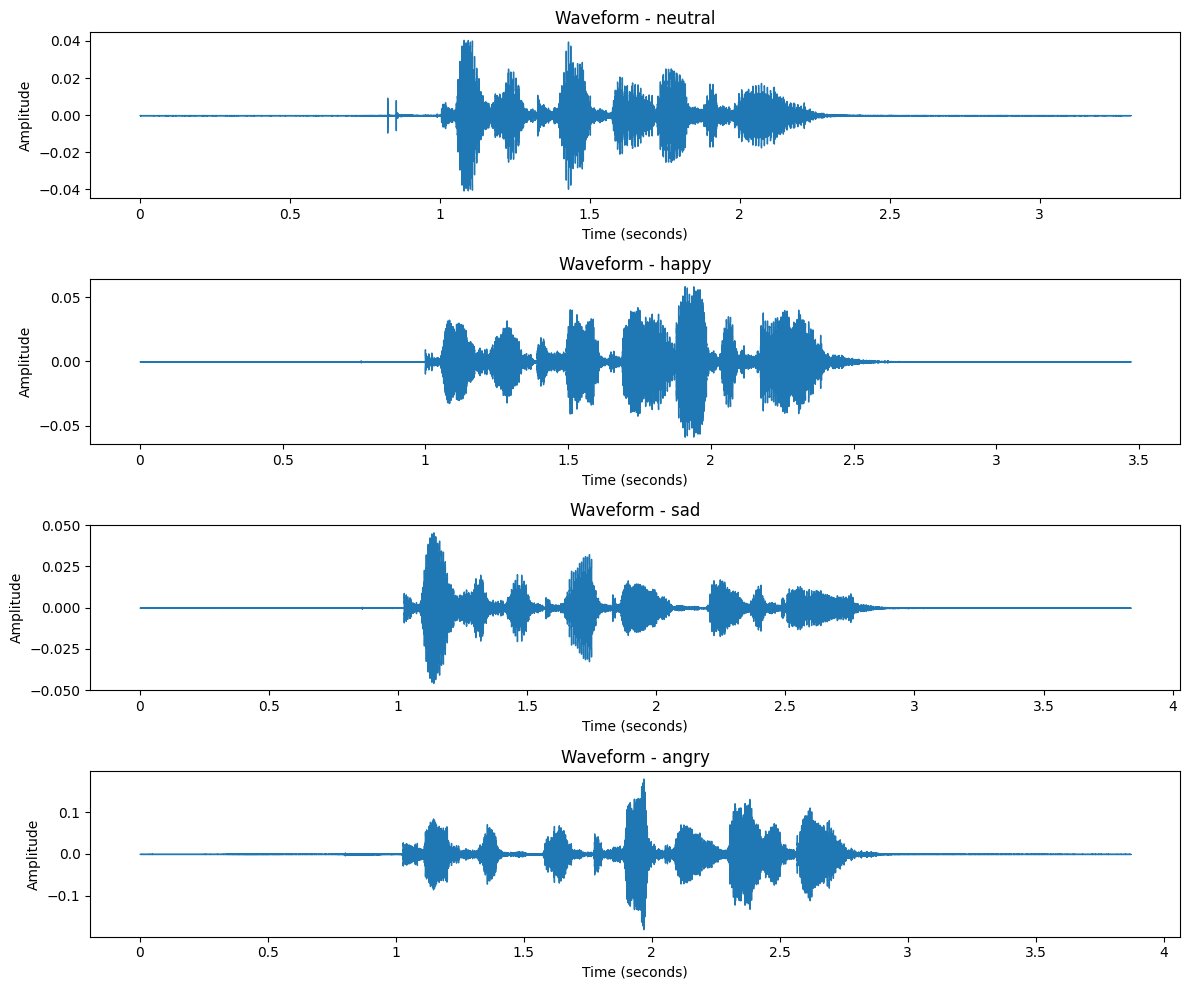

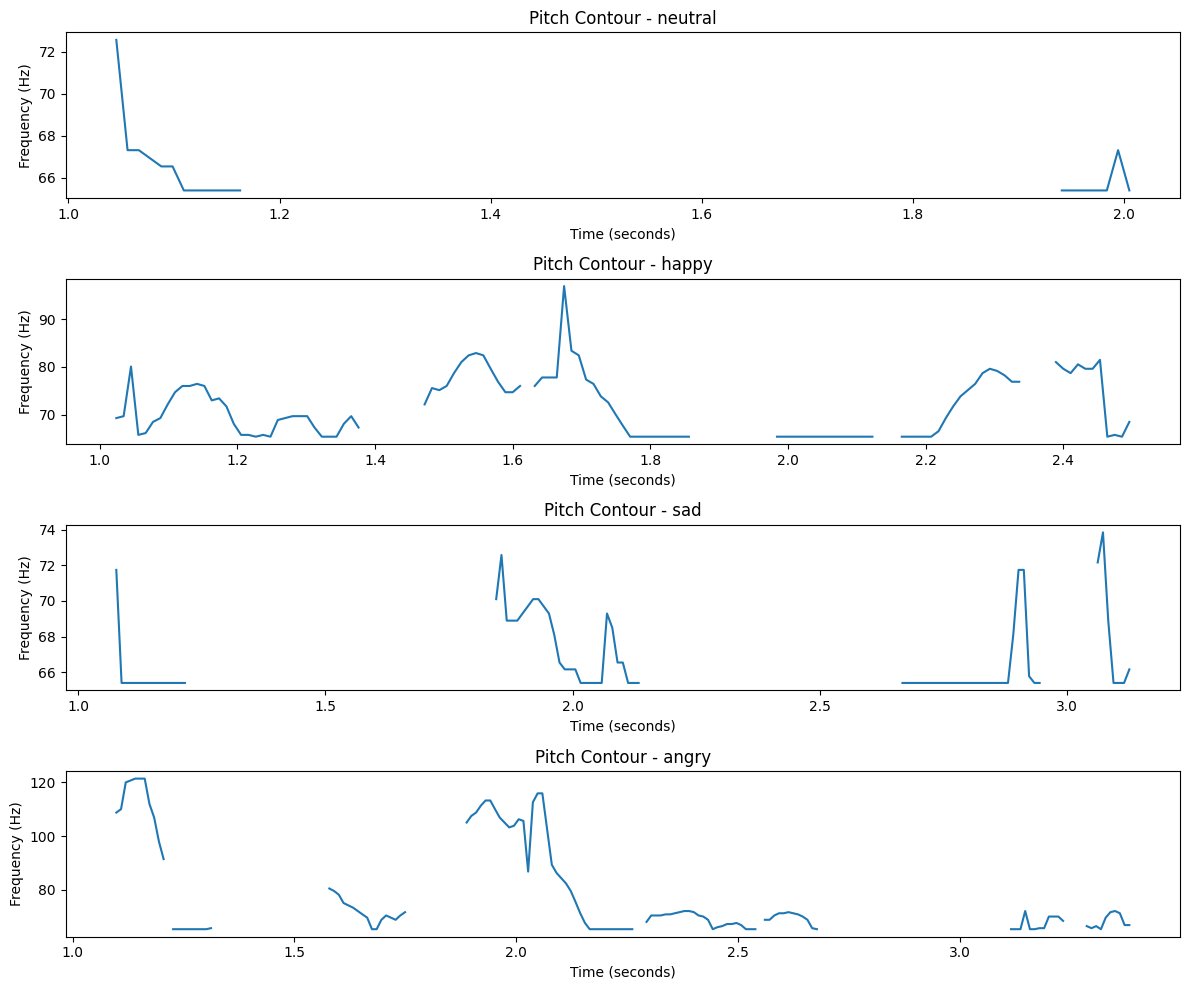

In [3]:
# Explore Audio

plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    plt.subplot(len(emotion_order), 1, i)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    f0, voiced_flag, voiced_probs = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )
    times = librosa.times_like(f0, sr=sr)

    plt.subplot(len(emotion_order), 1, i)
    plt.plot(times, f0)
    plt.title(f"Pitch Contour - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

The waveform shows where the speech is quiet and where the main voice activity appears.
In many samples, the amplitude becomes larger in the middle of the recording, which suggests the main speech segment.

The pitch contour shows how the speaker's fundamental frequency changes over time.
Some parts are missing because pitch is not detected in unvoiced sounds or silence.
These plots help show how speaking style and intonation may differ across emotions.

# Feature Extraction
In this section, I extract pitch-based features from the audio files.
These features summarize the pitch contour and will be used for model training.

Feature matrix shape: (672, 5)
Label shape: (672,)
Sample labels: ['neutral' 'neutral' 'neutral' 'neutral' 'happy' 'happy' 'happy' 'happy'
 'happy' 'happy']
First feature vector: [66.28700046  1.66379933 65.40639133 72.57293509  7.16654377]
Pitch contour shape: (310,)


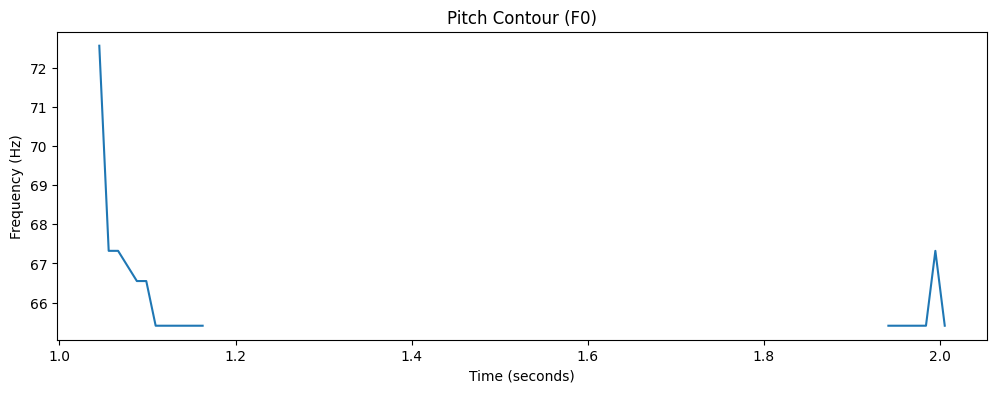

In [4]:
# Feature Extraction

selected_emotions = {"01", "03", "04", "05"}

X = []
y_labels = []

for file_path in audio_files:
    file_name = os.path.basename(file_path)
    emotion_code = file_name.split("-")[2]

    if emotion_code in selected_emotions:
        signal, sr = librosa.load(file_path, sr=None)

        # Get pitch values
        f0, voiced_flag, voiced_probs = librosa.pyin(
            signal,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7")
        )

        # Keep voiced frames
        f0_valid = f0[~np.isnan(f0)]

        # Skip empty pitch
        if len(f0_valid) == 0:
            continue

        # Build feature vector
        pitch_mean = np.mean(f0_valid)
        pitch_std = np.std(f0_valid)
        pitch_min = np.min(f0_valid)
        pitch_max = np.max(f0_valid)
        pitch_range = pitch_max - pitch_min

        feature_vector = np.array([
            pitch_mean,
            pitch_std,
            pitch_min,
            pitch_max,
            pitch_range
        ])

        X.append(feature_vector)
        y_labels.append(emotion_map[emotion_code])

X = np.array(X)
y_labels = np.array(y_labels)

print("Feature matrix shape:", X.shape)
print("Label shape:", y_labels.shape)
print("Sample labels:", y_labels[:10])
print("First feature vector:", X[0])

sample_file = audio_files[0]

y, sr = librosa.load(sample_file, sr=None)

f0, voiced_flag, voiced_probs = librosa.pyin(
    y,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7")
)

times = librosa.times_like(f0, sr=sr)

print("Pitch contour shape:", f0.shape)

plt.figure(figsize=(12, 4))
plt.plot(times, f0)
plt.title("Pitch Contour (F0)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()

In this step, I extract features based on **Pitch Contour (F0)**.

Because each audio file may have a different number of pitch frames, I convert the pitch contour into a fixed-length feature vector using summary statistics.

The extracted pitch-based features are:

- mean pitch
- standard deviation of pitch
- minimum pitch
- maximum pitch
- pitch range

These features are useful because they summarize both the overall pitch level and the amount of pitch variation.
This is important for emotion recognition, since emotional speech often differs in intonation and pitch movement.

# Model Training
In this section, I split the dataset into training and testing sets and train three machine learning models.
I use Random Forest, SVM, and Logistic Regression to classify emotions from the extracted pitch-based features.
The goal is to compare how well different models can recognize emotional expression from speech.

In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=1.0, gamma="scale")
    ),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42)
    )
}

trained_models = {}
predictions = {}

for name, model in models.items():
    print("\n" + "=" * 50)
    print(f"Training Model: {name}")

    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)

print("\nAll models have been trained.")

Training set shape: (537, 5)
Test set shape: (135, 5)

Training Model: Random Forest

Training Model: SVM

Training Model: Logistic Regression

All models have been trained.


# Evaluation
In this section, I evaluate the performance of all trained models using the test dataset.
I measure accuracy and examine the classification report and confusion matrix for each model.
These results help me compare model performance and understand how well the emotions are separated.


Evaluation for: Random Forest
Accuracy: 0.3851851851851852

Classification Report:
              precision    recall  f1-score   support

       angry       0.41      0.45      0.43        38
       happy       0.35      0.33      0.34        39
     neutral       0.24      0.21      0.22        19
         sad       0.45      0.46      0.46        39

    accuracy                           0.39       135
   macro avg       0.36      0.36      0.36       135
weighted avg       0.38      0.39      0.38       135

Confusion Matrix:
[[17 12  3  6]
 [10 13  4 12]
 [ 7  4  4  4]
 [ 7  8  6 18]]

Confusion Matrix DataFrame:
         angry  happy  neutral  sad
angry       17     12        3    6
happy       10     13        4   12
neutral      7      4        4    4
sad          7      8        6   18


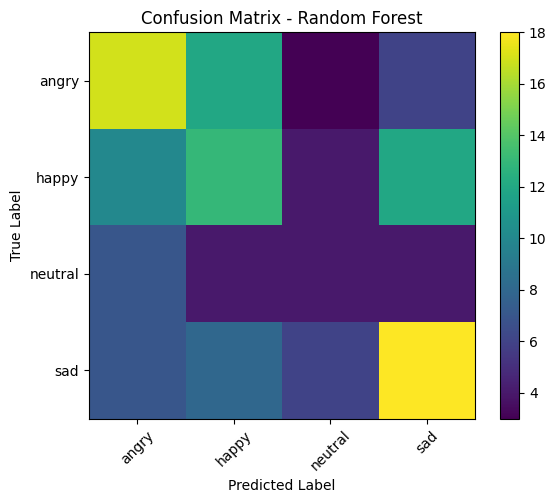


Evaluation for: SVM
Accuracy: 0.34074074074074073

Classification Report:
              precision    recall  f1-score   support

       angry       0.43      0.42      0.43        38
       happy       0.33      0.15      0.21        39
     neutral       0.00      0.00      0.00        19
         sad       0.30      0.62      0.40        39

    accuracy                           0.34       135
   macro avg       0.27      0.30      0.26       135
weighted avg       0.30      0.34      0.30       135

Confusion Matrix:
[[16  4  0 18]
 [10  6  0 23]
 [ 4  0  0 15]
 [ 7  8  0 24]]

Confusion Matrix DataFrame:
         angry  happy  neutral  sad
angry       16      4        0   18
happy       10      6        0   23
neutral      4      0        0   15
sad          7      8        0   24


c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

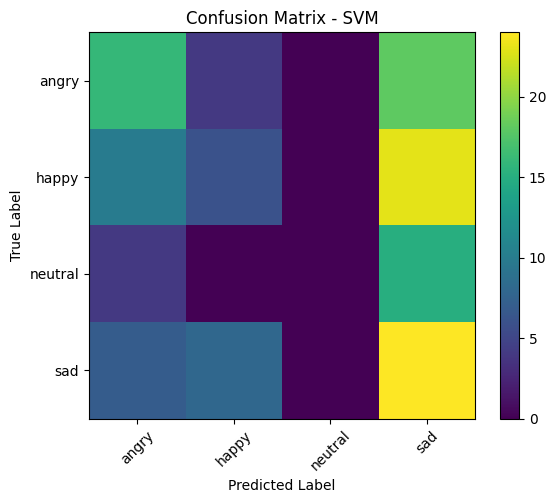


Evaluation for: Logistic Regression
Accuracy: 0.31851851851851853

Classification Report:
              precision    recall  f1-score   support

       angry       0.38      0.53      0.44        38
       happy       0.00      0.00      0.00        39
     neutral       0.00      0.00      0.00        19
         sad       0.29      0.59      0.39        39

    accuracy                           0.32       135
   macro avg       0.17      0.28      0.21       135
weighted avg       0.19      0.32      0.24       135

Confusion Matrix:
[[20  2  0 16]
 [13  0  0 26]
 [ 5  1  0 13]
 [14  2  0 23]]

Confusion Matrix DataFrame:
         angry  happy  neutral  sad
angry       20      2        0   16
happy       13      0        0   26
neutral      5      1        0   13
sad         14      2        0   23


c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

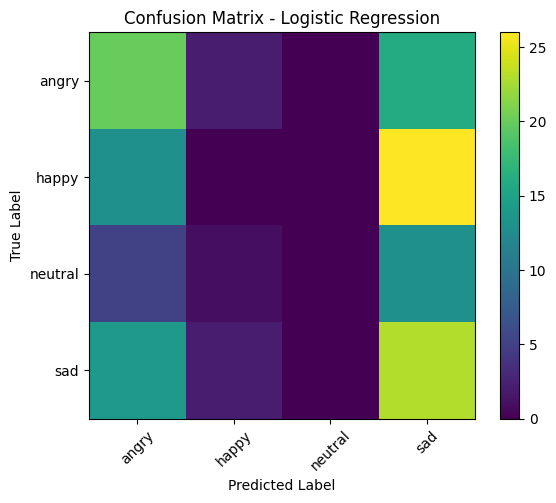


Summary of Results
                 Model  Accuracy
0        Random Forest  0.385185
1                  SVM  0.340741
2  Logistic Regression  0.318519


In [6]:
# Evaluation of all trained models

results = []

for name, y_pred in predictions.items():
    print("\n" + "=" * 60)
    print(f"Evaluation for: {name}")

    # Measure accuracy
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    print("Accuracy:", acc)

    # Show report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Build matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Get labels
    model = trained_models[name]
    if hasattr(model, "classes_"):
        class_labels = model.classes_
    else:
        class_labels = model.named_steps[list(model.named_steps.keys())[-1]].classes_

    cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
    print("\nConfusion Matrix DataFrame:")
    print(cm_df)

    # Plot matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()

    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels, rotation=45)
    plt.yticks(tick_marks, class_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\n" + "=" * 60)
print("Summary of Results")
print(results_df)

The accuracy score shows the overall performance of each model on the test data.
The classification report provides precision, recall, and F1-score for each emotion class.
The confusion matrix shows how often each emotion was correctly classified and where the models made mistakes.

These results help compare the models and show which emotions are easier or harder to distinguish from speech.

# Conclusion
In this notebook, I explored how speech audio can be used for emotion classification.
I extracted pitch-based features from the RAVDESS dataset and trained three machine learning models to predict emotions from speech.

The results suggest that speech contains useful patterns related to emotional expression, although some emotions may still be difficult to separate.
Overall, this project helped me understand the basic workflow of audio processing, feature extraction, model training, and evaluation in Google Colab.
In the future, the model could be improved by using richer spectral features or more advanced deep learning methods.